# Lung Cancer Regression Model

In [ ]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsRegressor

In [92]:
path = os.getcwd()

In [93]:
Lung_Data = pd.read_csv(f"{path}/Lung_Cancer_Trends_Realistic.csv")

In [94]:
Lung_Data.head()

,Patient_ID,Age,Gender,Smoking_Status,Years_Smoking,Cigarettes_Per_Day,Secondhand_Smoke_Exposure,Occupation_Exposure,Air_Pollution_Level,Family_History,...,Diet_Quality,Region,Income_Level,Education_Level,Access_to_Healthcare,Screening_Frequency,Chronic_Lung_Disease,Lung_Cancer_Stage,Diagnosis_Year,Survival_Status
0,P100000,76,Female,Never,6,37,Low,Diesel Fumes,Low,Yes,...,Poor,West,Middle,Tertiary,Good,Regularly,No,Stage II,2008,Alive
1,P100001,39,Male,Never,30,39,Low,Silica,Low,Yes,...,Average,North,Middle,Primary,Poor,Occasionally,Yes,NaN,2002,Alive
2,P100002,85,Male,Former,47,14,High,Asbestos,Low,Yes,...,Good,South,High,Tertiary,Average,Regularly,No,Stage II,2007,Deceased
3,P100003,45,Female,Current,45,32,Medium,Silica,High,No,...,Good,West,Low,Secondary,Average,Never,Yes,NaN,2011,Alive
4,P100004,48,Female,Never,46,26,Medium,Silica,Low,No,...,Good,North,Low,Tertiary,Average,Regularly,No,NaN,2016,Alive


In [95]:
Lung_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   object 
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   object 
 3   Smoking_Status             3000 non-null   object 
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   object 
 7   Occupation_Exposure        2256 non-null   object 
 8   Air_Pollution_Level        3000 non-null   object 
 9   Family_History             3000 non-null   object 
 10  Genetic_Markers_Positive   3000 non-null   object 
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   object 
 13  Alcohol_Consumption        2025 non-null   objec

In [96]:
Lung_Data['Occupation_Exposure'].unique()
#Lung_Data['Occupation_Exposure'] = Lung_Data['Occupation_Exposure'].fillna('Unkown')
Lung_Data['Occupation_Exposure'].unique()

array(['Diesel Fumes', 'Silica', 'Asbestos', nan], dtype=object)

In [97]:
Lung_Data['Alcohol_Consumption'].unique()
#Lung_Data['Alcohol_Consumption'] = Lung_Data['Alcohol_Consumption'].fillna('Unknown')
Lung_Data['Alcohol_Consumption'].unique()

array(['Moderate', 'High', nan], dtype=object)

In [129]:
Lung_Data['Survival_Status']

0       0
1       0
2       1
3       0
4       0
       ..
2995    0
2996    1
2997    0
2998    0
2999    0
Name: Survival_Status, Length: 3000, dtype: int64

In [99]:
Lung_Data['Lung_Cancer_Stage'].unique()
#Lung_Data['Lung_Cancer_Stage'] = Lung_Data['Lung_Cancer_Stage'].fillna('Unkown')
Lung_Data['Lung_Cancer_Stage'].unique()

array(['Stage II', nan, 'Stage III', 'Stage IV', 'Stage I'], dtype=object)

In [100]:
Lung_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   object 
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   object 
 3   Smoking_Status             3000 non-null   object 
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   object 
 7   Occupation_Exposure        2256 non-null   object 
 8   Air_Pollution_Level        3000 non-null   object 
 9   Family_History             3000 non-null   object 
 10  Genetic_Markers_Positive   3000 non-null   object 
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   object 
 13  Alcohol_Consumption        2025 non-null   objec

In [101]:
Lung_Data = pd.DataFrame(Lung_Data)

## Exploratory Data Analysis

In [102]:
Lung_Data.describe()

,Age,Years_Smoking,Cigarettes_Per_Day,BMI,Diagnosis_Year
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,56.654333,24.226000,19.624000,24.972633,2012.129667
std,18.740880,14.292924,11.430289,4.962199,7.248105
min,25.000000,0.000000,0.000000,2.600000,2000.000000
25%,41.000000,12.000000,10.000000,21.600000,2006.000000
50%,57.000000,24.000000,19.000000,24.800000,2012.000000
75%,73.000000,36.000000,29.000000,28.300000,2018.000000
max,89.000000,49.000000,39.000000,45.700000,2024.000000


In [103]:
#print('Number columns' ,Lung_Data.select_dtypes(include=['int64','float64']).columns)

In [104]:
print('String columns' ,Lung_Data.select_dtypes(include='object').columns)

String columns Index(['Patient_ID', 'Gender', 'Smoking_Status', 'Secondhand_Smoke_Exposure',
       'Occupation_Exposure', 'Air_Pollution_Level', 'Family_History',
       'Genetic_Markers_Positive', 'Physical_Activity_Level',
       'Alcohol_Consumption', 'Diet_Quality', 'Region', 'Income_Level',
       'Education_Level', 'Access_to_Healthcare', 'Screening_Frequency',
       'Chronic_Lung_Disease', 'Lung_Cancer_Stage', 'Survival_Status'],
      dtype='object')


In [105]:

strings= Lung_Data[['Patient_ID', 'Gender', 'Smoking_Status', 'Secondhand_Smoke_Exposure',
       'Occupation_Exposure', 'Air_Pollution_Level', 'Family_History',
       'Genetic_Markers_Positive', 'Physical_Activity_Level',
       'Alcohol_Consumption', 'Diet_Quality', 'Region', 'Income_Level',
       'Education_Level', 'Access_to_Healthcare', 'Screening_Frequency',
       'Chronic_Lung_Disease', 'Lung_Cancer_Stage', 'Survival_Status']]

strings = pd.DataFrame(strings)


In [ ]:

for column in strings:
    Encode = LabelEncoder()
    Lung_Data[column] = Encode.fit_transform(Lung_Data[column])
    print(f"{column} Unique values after conversion= {Lung_Data[column].unique()}")

   

Patient_ID Unique values after conversion= [   0    1    2 ... 2997 2998 2999]
Gender Unique values after conversion= [0 1]
Smoking_Status Unique values after conversion= [2 1 0]
Secondhand_Smoke_Exposure Unique values after conversion= [1 0 2]
Occupation_Exposure Unique values after conversion= [1 2 0 3]
Air_Pollution_Level Unique values after conversion= [1 0 2]
Family_History Unique values after conversion= [1 0]
Genetic_Markers_Positive Unique values after conversion= [0 1]
Physical_Activity_Level Unique values after conversion= [2 0 1]
Alcohol_Consumption Unique values after conversion= [1 0 2]
Diet_Quality Unique values after conversion= [2 0 1]
Region Unique values after conversion= [3 1 2 0]
Income_Level Unique values after conversion= [2 0 1]
Education_Level Unique values after conversion= [2 0 1]
Access_to_Healthcare Unique values after conversion= [1 2 0]
Screening_Frequency Unique values after conversion= [2 1 0]
Chronic_Lung_Disease Unique values after conversion= [0 1]
Lu

Alive = 0 
Deceased = 1

In [107]:
#Lung_Data.drop(['Patient_ID','Education_Level','Income_Level','Diagnosis_Year'], axis= 1)

In [108]:
#Lung_Data.info()

In [109]:
#Lung_Data['Lung_Cancer_Stage'].value_counts()

In [110]:
X = Lung_Data.drop(['Survival_Status','Patient_ID'], axis=1)
y = Lung_Data['Survival_Status']

In [111]:
y = pd.DataFrame(y)
type(y)

pandas.core.frame.DataFrame

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=50)

In [113]:
print(y_train.shape)

(2400, 1)


In [114]:
"""
scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.fit_transform(X_test)
Y_train_scale = scale.fit_transform(y_train)
Y_test_scale = scale.fit_transform(y_test)
"""

'\nscale = StandardScaler()\nX_train_scale = scale.fit_transform(X_train)\nX_test_scale = scale.fit_transform(X_test)\nY_train_scale = scale.fit_transform(y_train)\nY_test_scale = scale.fit_transform(y_test)\n'

In [123]:
ln_1 = LogisticRegression(max_iter = 100000, random_state=0)
ln_1.fit(X_train,y_train)

ln_1_perd = ln_1.predict(X_test)
ln_1_prob = ln_1.predict_proba(X_test)[:, 1]

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

In [124]:
print("Accuracy:", accuracy_score(y_test, ln_1_perd))
print("Precision:", precision_score(y_test, ln_1_perd , average='weighted'))
print("Recall:", recall_score(y_test, ln_1_perd, average='weighted'))
print("F1 Score:", f1_score(y_test, ln_1_perd, average='weighted'))
#print("AUC-ROC:", roc_auc_score(y_test, ln_1_perd, multi_class='ovr'))

Accuracy: 0.8366666666666667
Precision: 0.7000111111111111
Recall: 0.8366666666666667
F1 Score: 0.7622625529340593


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rfc_pred = rfc.predict(X_train)

tn, fp, fn, tp = confusion_matrix(y_test, rfc_pred).ravel()


In [ ]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print("Accuracy:", accuracy_score(y_test, rfc_pred))
print("Precision:", precision_score(y_test, rfc_pred , average='weighted'))
print("Recall:", recall_score(y_test, rfc_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rfc_pred, average='weighted'))

In [125]:
rep = classification_report(y_test,ln_1_perd.round(), output_dict = True)

rep = pd.DataFrame(rep).transpose();

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [126]:
y_train.value_counts()

Survival_Status
0                  2032
1                   368
Name: count, dtype: int64

In [127]:
rep

,precision,recall,f1-score,support
0,0.836667,1.000000,0.911071,502.000000
1,0.000000,0.000000,0.000000,98.000000
accuracy,0.836667,0.836667,0.836667,0.836667
macro avg,0.418333,0.500000,0.455535,600.000000
weighted avg,0.700011,0.836667,0.762263,600.000000


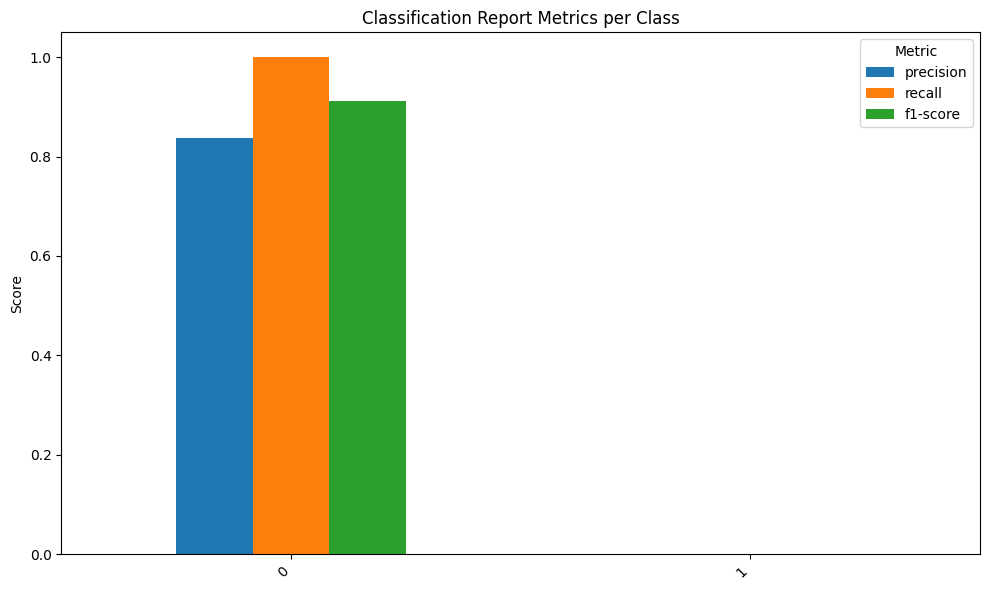

In [120]:
metrics_to_plot = ['precision', 'recall', 'f1-score']
df_plot = rep.loc[rep.index.difference(['accuracy', 'macro avg', 'weighted avg']), metrics_to_plot]

df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Classification Report Metrics per Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()